# Reflection Agent using LangGraph and ChatGroq

This notebook implements:

- ChatGroq only
- Draft generation
- Structured critique
- Conditional revision loop
- Maximum revision limit
- Final answer generation

```text
User query
   ↓
Generate draft
   ↓
Critique
   ↓
Approved?
   ├── Yes → Finalize
   └── No  → Revise → Critique again
```


## Cell 1: Install Libraries

In [1]:
# %pip install -U langgraph langchain langchain-groq python-dotenv pydantic


## Cell 2: Import Libraries

In [2]:
import os
from typing import Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


## Cell 3: Load Groq API Key

Create a `.env` file:

```text
GROQ_API_KEY=your_groq_api_key
```


In [3]:
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY_S")

if not groq_api_key:
    raise ValueError(
        "GROQ_API_KEY was not found. Add it to your .env file."
    )


## Cell 4: Initialize ChatGroq

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=groq_api_key,
    max_retries=2,
    timeout=60,
)


## Cell 5: Define Structured Critique Output

In [5]:
class CritiqueResult(BaseModel):
    is_satisfactory: bool = Field(
        description=(
            "True when the answer fully satisfies the user request "
            "and requires no revision."
        )
    )

    score: int = Field(
        ge=1,
        le=10,
        description="Overall answer-quality score from 1 to 10."
    )

    strengths: list[str] = Field(
        description="Important strengths of the current answer."
    )

    weaknesses: list[str] = Field(
        description=(
            "Specific problems, missing details, or unclear sections."
        )
    )

    improvement_instructions: list[str] = Field(
        description=(
            "Concrete instructions for improving the next revision."
        )
    )


critic_llm = llm.with_structured_output(CritiqueResult)


## Cell 6: Define Reflection State

In [6]:
class ReflectionState(TypedDict, total=False):
    user_query: str
    draft_answer: str
    critique: CritiqueResult
    revision_count: int
    max_revisions: int
    final_answer: str


## Cell 7: Define Prompts

In [7]:
GENERATOR_SYSTEM_PROMPT = """
You are an expert answer-generation agent.

Create a complete, accurate and well-structured answer
for the user's request.

Requirements:
- Directly answer the request.
- Use clear headings when useful.
- Include examples where appropriate.
- Avoid unnecessary repetition.
- Do not mention the reflection process.
- Do not say that the answer is a draft.
"""


CRITIC_SYSTEM_PROMPT = """
You are a strict answer-quality evaluator.

Evaluate the answer against the user's original request.

Check:
1. Correctness
2. Completeness
3. Relevance
4. Clarity
5. Logical structure
6. Practical usefulness
7. Examples where needed
8. Unsupported claims
9. Repetition
10. Instruction following

Set is_satisfactory to true only when:
- the answer fully addresses the request,
- there are no major factual or logical problems,
- important details are not missing,
- and the score is at least 8.

Provide specific and actionable improvement instructions.
"""


REVISION_SYSTEM_PROMPT = """
You are an expert answer-revision agent.

Improve the current answer using the provided critique.

Instructions:
- Preserve all correct and useful content.
- Fix every identified weakness.
- Follow the improvement instructions.
- Improve completeness and clarity.
- Remove repetition.
- Do not mention the critique.
- Do not mention that the answer was revised.
- Return only the improved answer.
"""


## Cell 8: Generate Draft Node

In [8]:
def generate_draft_node(
    state: ReflectionState,
) -> dict:
    """Generate the initial answer."""

    response = llm.invoke(
        [
            SystemMessage(content=GENERATOR_SYSTEM_PROMPT),
            HumanMessage(content=state["user_query"]),
        ]
    )

    return {
        "draft_answer": response.content,
        "revision_count": 0,
    }


## Cell 9: Critique Node

In [9]:
def critique_node(
    state: ReflectionState,
) -> dict:
    """Evaluate the current draft using structured output."""

    critique = critic_llm.invoke(
        [
            SystemMessage(content=CRITIC_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"Original user request:\n"
                    f"{state['user_query']}\n\n"
                    f"Answer to evaluate:\n"
                    f"{state['draft_answer']}"
                )
            ),
        ]
    )

    return {"critique": critique}


## Cell 10: Conditional Routing

In [10]:
def route_after_critique(
    state: ReflectionState,
) -> Literal["revise", "finalize"]:
    """Decide whether another revision is needed."""

    critique = state["critique"]
    revision_count = state.get("revision_count", 0)
    max_revisions = state.get("max_revisions", 2)

    if critique.is_satisfactory:
        return "finalize"

    if revision_count >= max_revisions:
        return "finalize"

    return "revise"


## Cell 11: Revision Node

In [11]:
def revise_answer_node(
    state: ReflectionState,
) -> dict:
    """Revise the answer using critic feedback."""

    critique = state["critique"]

    strengths = "\n".join(
        f"- {item}" for item in critique.strengths
    )

    weaknesses = "\n".join(
        f"- {item}" for item in critique.weaknesses
    )

    instructions = "\n".join(
        f"- {item}"
        for item in critique.improvement_instructions
    )

    critique_text = f"""
Score: {critique.score}/10

Strengths:
{strengths}

Weaknesses:
{weaknesses}

Improvement instructions:
{instructions}
"""

    response = llm.invoke(
        [
            SystemMessage(content=REVISION_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"Original user request:\n"
                    f"{state['user_query']}\n\n"
                    f"Current answer:\n"
                    f"{state['draft_answer']}\n\n"
                    f"Critique:\n"
                    f"{critique_text}"
                )
            ),
        ]
    )

    return {
        "draft_answer": response.content,
        "revision_count": state.get("revision_count", 0) + 1,
    }


## Cell 12: Finalize Node

In [12]:
def finalize_node(
    state: ReflectionState,
) -> dict:
    """Store the latest answer as the final answer."""

    return {
        "final_answer": state["draft_answer"]
    }


## Cell 13: Build the LangGraph

In [13]:
builder = StateGraph(ReflectionState)

builder.add_node("generate_draft", generate_draft_node)
builder.add_node("critique", critique_node)
builder.add_node("revise", revise_answer_node)
builder.add_node("finalize", finalize_node)

builder.add_edge(START, "generate_draft")
builder.add_edge("generate_draft", "critique")

builder.add_conditional_edges(
    "critique",
    route_after_critique,
    {
        "revise": "revise",
        "finalize": "finalize",
    },
)

builder.add_edge("revise", "critique")
builder.add_edge("finalize", END)

reflection_agent = builder.compile()


Graph flow:

```text
START
  ↓
Generate draft
  ↓
Critique
  ↓
Is satisfactory?
  ├── Yes → Finalize → END
  └── No  → Revise → Critique
```


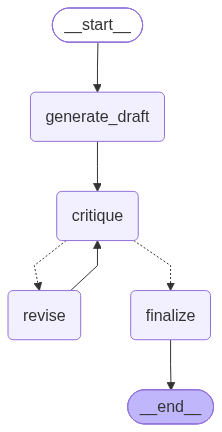

In [14]:
# ==========================================================
# Cell 6 : Visualize the LangGraph Workflow
# ==========================================================

from IPython.display import Image, display

# Display the graph
display(
    Image(
        reflection_agent.get_graph().draw_mermaid_png()
    )
)

## Cell 14: Define Test Query

In [15]:
user_query = """
Explain Retrieval-Augmented Generation for a data
scientist interview.

Include:
- definition,
- complete workflow,
- importance of embeddings,
- vector database,
- retrieval,
- generation,
- advantages,
- limitations,
- and a practical example.

Keep the answer suitable for someone with around
three years of data-science experience.
"""


## Cell 15: Run Reflection Agent

In [16]:
result = reflection_agent.invoke(
    {
        "user_query": user_query,
        "max_revisions": 2,
    },
    config={
        "recursion_limit": 15,
    },
)

print(result["final_answer"])


## Introduction to Retrieval-Augmented Generation
Retrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) that combines the strengths of information retrieval and text generation models. It aims to generate more accurate and informative text by leveraging the power of retrieval to fetch relevant information from a large corpus of text, which is then used to augment the generation process.

## Workflow of Retrieval-Augmented Generation
The workflow of RAG involves the following steps:
1. **Text Encoding**: The input text is encoded into a dense vector representation using an embedding model.
2. **Retrieval**: The encoded input vector is used to query a vector database that stores a large corpus of text, each represented as a vector. The retrieval step fetches the most relevant documents or passages from the database.
3. **Generation**: The retrieved documents or passages are then used to condition a text generation model, which produces the final ou

## Cell 16: Inspect Final Critique

In [17]:
critique = result["critique"]

print("Final score:", critique.score)
print("Satisfactory:", critique.is_satisfactory)
print("Revision count:", result["revision_count"])

print("\nStrengths:")
for strength in critique.strengths:
    print("-", strength)

print("\nWeaknesses:")
for weakness in critique.weaknesses:
    print("-", weakness)

print("\nImprovement instructions:")
for instruction in critique.improvement_instructions:
    print("-", instruction)


Final score: 9
Satisfactory: True
Revision count: 0

Strengths:
- The answer provides a clear and concise definition of Retrieval-Augmented Generation
- The workflow of RAG is well-explained and easy to follow
- The importance of embeddings, vector database, retrieval, and generation are well-discussed
- The answer provides a practical example of RAG in a question answering system

Weaknesses:
- Some sections, such as the introduction, could be more concise
- The answer could benefit from more visual aids, such as diagrams or flowcharts, to illustrate the workflow of RAG

Improvement instructions:
- Consider adding more visual aids to illustrate the workflow of RAG
- Provide more examples of RAG in different NLP tasks, such as text summarization or dialogue generation
- Discuss potential applications of RAG in industry or research


## Cell 17: Stream Reflection Updates

In [18]:
for event in reflection_agent.stream(
    {
        "user_query": user_query,
        "max_revisions": 2,
    },
    config={
        "recursion_limit": 15,
    },
    stream_mode="updates",
):
    print("=" * 80)

    for node_name, update in event.items():
        print("Node:", node_name)

        if "revision_count" in update:
            print(
                "Revision count:",
                update["revision_count"],
            )

        if "critique" in update:
            current_critique = update["critique"]

            print("Score:", current_critique.score)
            print(
                "Satisfactory:",
                current_critique.is_satisfactory,
            )

        if "draft_answer" in update:
            print(
                "Answer preview:",
                update["draft_answer"][:300],
            )


Node: generate_draft
Revision count: 0
Answer preview: ## Introduction to Retrieval-Augmented Generation
Retrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) that combines the strengths of information retrieval and text generation models. It aims to generate more accurate and informative text by leveraging the po
Node: critique
Score: 9
Satisfactory: True
Node: finalize


# Step-by-Step Logic

1. `generate_draft` creates the first answer.
2. `critique` evaluates it using `CritiqueResult`.
3. `route_after_critique` checks quality and revision count.
4. `revise` improves an unsatisfactory answer.
5. The revised answer returns to `critique`.
6. The loop stops when approved or when `max_revisions` is reached.
7. `finalize` copies the latest answer into `final_answer`.
